##Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("IPL.csv")
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

####check size of rows and columns of the dataset

In [6]:
print(f"Number of Rows: {df.shape[0]}")
print(f'Number of Columns: {df.shape[1]}')

Number of Rows: 74
Number of Columns: 20


##how many columns ahve null values in total

In [62]:
df.isna().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


##1.which team won the most matches?

<Axes: ylabel='match_winner'>

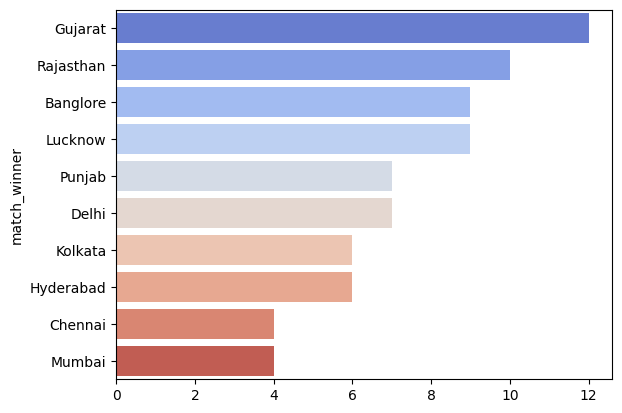

In [63]:
win=df['match_winner'].value_counts()
sns.barplot(y=win.index,x=win.values,palette="coolwarm")

##2.Toss decisions

<Axes: xlabel='toss_decision', ylabel='count'>

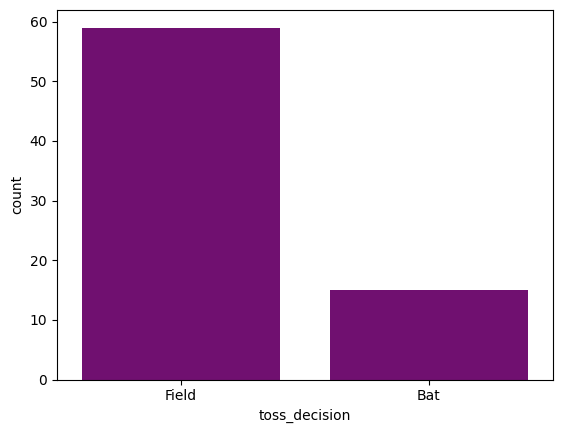

In [9]:
sns.countplot(x=df["toss_decision"],color="Purple")

##3.Toss winner vs Match winner

In [10]:
count= df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage= (count*100)/df.shape[0]
percentage.round(2)
count

np.int64(36)

##4.How do teams win? (Runs vs Wickets)

<Axes: xlabel='won_by', ylabel='count'>

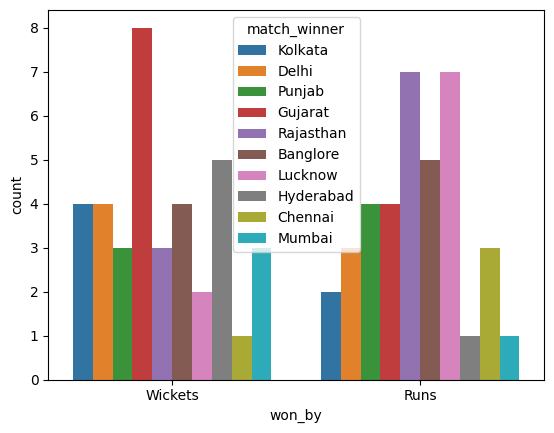

In [11]:
sns.countplot(x=df['won_by'],hue=df['match_winner'])

##Key Player Performances
####1. Most "Player of the match" Awards

In [12]:
count=df['player_of_the_match'].value_counts()
pom=count.head(10)

Text(0.5, 1.0, 'Top 10 players to get players of the match Award')

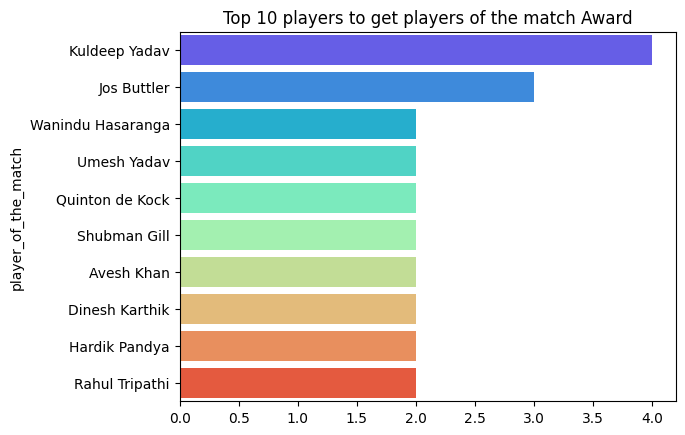

In [13]:
sns.barplot(x=pom.values,y=pom.index,palette="rainbow")
plt.title("Top 10 players to get players of the match Award")

2. Top Scorers

In [19]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False)
top_scorer=high.head(2)


Text(0.5, 1.0, 'Top 2 high scorers of all')

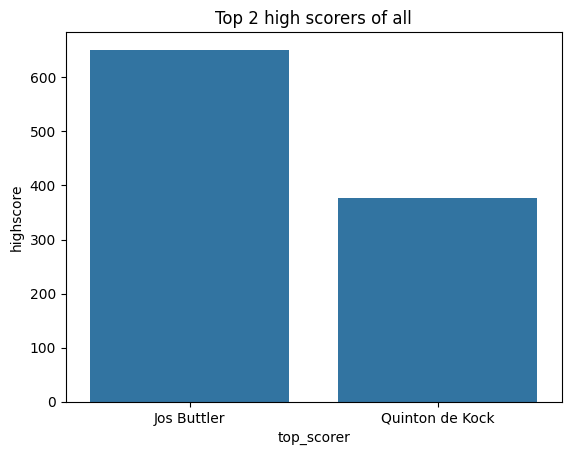

In [23]:
sns.barplot(top_scorer)
plt.title("Top 2 high scorers of all")

##3. 10 Best Bowling Figures

In [38]:
df["highest_wickets"] = df['best_bowling_figure'].apply(lambda x : x.split("--")[0])
df['highest_wickets'] = df["highest_wickets"].astype(int)
df
top_bowlers = df.groupby("best_bowling")['highest_wickets'].sum().sort_values(ascending=False)
top_bowlers1=top_bowlers.head(10)

<Axes: ylabel='best_bowling'>

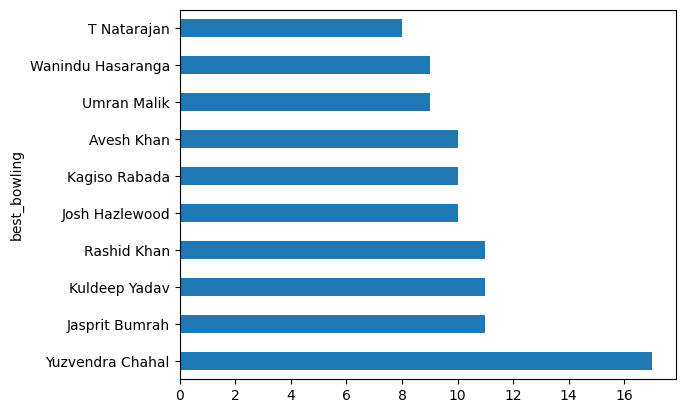

In [45]:
top_bowlers1.plot(kind="barh")

##4. Most matches played by venue

<Axes: xlabel='count', ylabel='venue'>

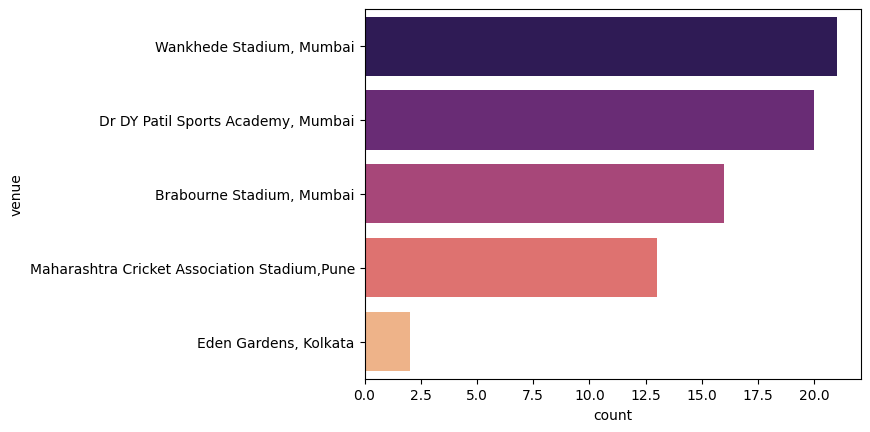

In [60]:
venue=df["venue"].value_counts().head(5)
sns.barplot(x=venue,y=venue.index,palette="magma")

##Q1. who won the highest margin by runs

In [78]:
df[df["won_by"]=="Runs"].sort_values(by="margin",ascending=False).head(1)[["match_winner","margin"]]

,match_winner,margin
54,Chennai,91


##Q2. which player has the highest individual score?

In [86]:
df[df['highscore']== df["highscore"].max()][["top_scorer","highscore"]]

,top_scorer,highscore
65,Quinton de Kock,140


##Q3. which bowler had the best bowling figures?

In [87]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


In [92]:
best_bowl=df[df['highest_wickets']==df['highest_wickets'].max()][["best_bowling","best_bowling_figure"]]
best_bowl.sort_values(by="best_bowling_figure")

,best_bowling,best_bowling_figure
55,Jasprit Bumrah,5--10
53,Wanindu Hasaranga,5--18
39,Umran Malik,5--25
29,Yuzvendra Chahal,5--40
